# Clase 2: Colapso y Formación


## Objetivos
1. Formalización y Solución de la Esfera de Bonnor-Ebert.
2. El Colapso de "Adentro hacia Afuera" (Inside-Out Collapse) de Frank Shu.
3. Clasificación Observacional de Objetos Estelares Jóvenes (YSOs).
4. Evolución en la Pre-Secuencia Principal (PMS).


## Formalización y Solucieon de la Esfera de Bonnor-Ebert
### 1.1 La Solución Completa de la Esfera de Bonnor-Ebert:

Como vimos en la clase anterior, la aproximación de Jeans asume un medio infinito homogéneo, lo cual genera paradojas físicas. La Esfera de Bonnor-Ebert (BE) resuelve esto modelando un núcleo de gas isotérmico finito confinado por la presión externa del medio interestelar ($P_{ext}$).

1.1 Formulación Matemática Rigurosa
Partimos del equilibrio hidrostático esférico y la ecuación de Poisson para un gas isotérmico ideal ($P=\rho c^2_s$):

$$
\frac{1}{r^2}\frac{d}{dr}\left( \frac{r^2}{\rho} \frac{d\rho}{dr} \right) = \frac{4\pi G}{c^2_s}ρ
$$

Definimos el potencial adimensional $\psi=−ln(\frac{\rho}{\rho_c})$ y el radio adimensional $\xi=\frac{r}{r_0}$, donde la escala de longitud característica es:

$$
r_0=\left(\frac{c^2_s}{4\pi G \rho_c} \right)^{1/2}
$$

Sustituyendo esto, llegamos a la Ecuación de Lane-Emden Isotérmica:

$$
\frac{1}{\xi^2}\frac{d}{d\xi}\left( \xi^2 \frac{d\psi}{d\xi} \right) = e^{-\psi}
$$

con condiciones de frontera en el centro: $\psi(0)=0$ y $\psi'(0)=0$.

### 1.2 El Límite de Estabilidad y la Masa Crítica
Integrando la densidad desde el centro hasta el radio adimensional del borde ($\xi_R$), la masa total de la esfera se expresa como:

$$
M=m(\xi_R)\frac{c^4_s}{G^{3/2}P_{ext}^{1/2}}
$$

donde $m(\xi_R)=\frac{1}{\sqrt(4\pi)}e^{-\psi_R/2}\left( \xi^2\frac{d\psi}{d\xi} \right)_{\xi_R}$ es la función de masa adimensional.

* A medida que el núcleo se contrae y aumenta su concentración central, ($m(\xi_R)$) crece hasta alcanzar un máximo estricto en:

$$
\xi_{crit}\approx6.451
$$

* En este punto crítico, la función de masa adimensional toma el valor $m(6.451)\approx1.18$, y el contraste de densidad central frente al borde es:

$$
\left( \frac{\rho_c}{\rho_R} \right)_{crit}=e^{\psi(6.451)}\approx14.04
$$

* Criterio Físico: Si $\rho_c / \rho_R>14.04$, no existe ninguna solución estática de equilibrio hidrostático. La gravedad supera por completo la presión térmica y el núcleo experimenta un colapso gravitacional incontrolado.

* Por lo tanto, la Masa Crítica de Bonnor-Ebert que marca el umbral de estabilidad es:

$$
M_{BE} = 1.18\frac{c^4_s}{G^{3/2}P_{ext}^{1/2}}
$$


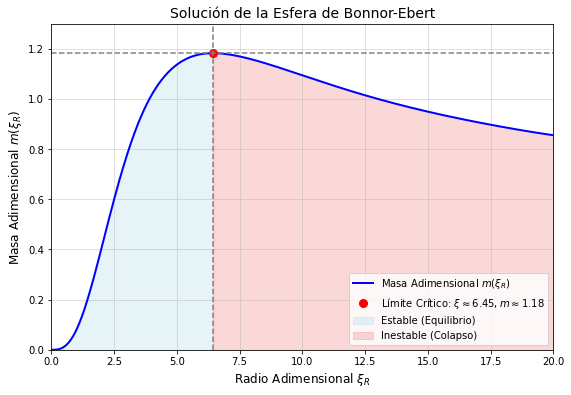

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Definir la Ecuación de Lane-Emden Isotérmica
def lane_emden_isothermal(xi, y):
    psi, dpsi_dxi = y
    if xi == 0:
        return [0, 0] # Evitar división por cero
    d2psi_dxi2 = np.exp(-psi) - (2.0 / xi) * dpsi_dxi
    return [dpsi_dxi, d2psi_dxi2]

# Condiciones iniciales cerca del centro (usando expansión de Taylor)
xi_0 = 1e-4
psi_0 = (xi_0**2) / 6.0
dpsi_0 = xi_0 / 3.0
y0 = [psi_0, dpsi_0]

# Integración numérica
xi_eval = np.linspace(xi_0, 20.0, 1000)
sol = solve_ivp(lane_emden_isothermal, (xi_0, 20.0), y0, t_eval=xi_eval, method='RK45')

xi = sol.t
psi = sol.y[0]
dpsi = sol.y[1]

# Calcular la Masa Adimensional m(xi)
m_xi = (1.0 / np.sqrt(4 * np.pi)) * np.exp(-psi / 2.0) * (xi**2) * dpsi

# Encontrar el punto crítico (Máximo)
max_idx = np.argmax(m_xi)
xi_crit = xi[max_idx]
m_crit = m_xi[max_idx]

# Visualización
plt.figure(figsize=(9, 6))
plt.plot(xi, m_xi, 'b-', linewidth=2, label='Masa Adimensional $m(\\xi_R)$')
plt.plot(xi_crit, m_crit, 'ro', markersize=8, label=f'Límite Crítico: $\\xi \\approx {xi_crit:.2f}, m \\approx {m_crit:.2f}$')

plt.axvline(xi_crit, color='gray', linestyle='--')
plt.axhline(m_crit, color='gray', linestyle='--')
plt.fill_between(xi, m_xi, where=(xi <= xi_crit), color='lightblue', alpha=0.3, label='Estable (Equilibrio)')
plt.fill_between(xi, m_xi, where=(xi > xi_crit), color='lightcoral', alpha=0.3, label='Inestable (Colapso)')

plt.title('Solución de la Esfera de Bonnor-Ebert', fontsize=14)
plt.xlabel('Radio Adimensional $\\xi_R$', fontsize=12)
plt.ylabel('Masa Adimensional $m(\\xi_R)$', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.5)
plt.xlim(0, 20)
plt.ylim(0, 1.3)
plt.show()

## 2. El Colapso de "Adentro hacia Afuera" (Inside-Out Collapse) de Frank Shu (1977).

El modelo analítico clásico para describir cómo un núcleo pre-estelar estable comienza a colapsar es la Esfera Isoterma Singular (SIS) desarrollada por Frank Shu.

### 2.1 El Perfil Inicial de la SIS.

Antes del colapso, un núcleo crítico maduro desarrolla un perfil de densidad muy característico gobernado puramente por la gravedad auto-sostenida isothermal:

$$
\rho(r) = \frac{c_s^2}{2\pi Gr^2}
$$

Notar que en el centro ($r→0$), la densidad tiende a infinito (por eso se denomina "singular").

### 2.2 La Onda de Rarefacción y el Colapso Dinámico.

Cuando el centro del núcleo pierde el equilibrio, el colapso no ocurre simultáneamente en toda la nube.

1. Se forma un colapso puntual en el centro absoluto ($r=0$).
2. Una perturbación de presión (una onda de rarefacción o frente de onda sónica) se propaga hacia afuera a la velocidad del sonido $c_s$.
3. El radio de esta onda en un tiempo $t$ es el radio sónico:

$$
r_s=c_st
$$

  - Región Exterior ($r>r_s$): El gas permanece casi estático, manteniendo el perfil inicial de la esfera singular ($\rho\propto r^{-2}$).
  - Región Interior ($r<r_s$): El gas ha sentido la pérdida de presión y cae libremente hacia el centro, adoptando un perfil de velocidad en caída libre y un perfil de densidad:

$$
\rho(r)\propto r^{-3/2}
$$

### 2.3 Tasa de Acreción Constante.

Una de las predicciones más potentes y elegantes del modelo de Shu es que, a medida que la onda expansiva avanza hacia las capas externas de la nube, la tasa a la cual la masa cae hacia la protoestrella central ($\dot{M}$) permanece estrictamente constante en el tiempo:

$$
\dot{M}= m_0\frac{c_s^3}{G}
$$

donde $m_0$ es un parámetro numérico adimensional derivado de la solución de autosemejanza de Shu ($m_0\approx0.975$).

Para una nube típica con $T=10$K ($c_s\approx0.2$km/s), esta tasa predice un valor característico de:

$$
\dot{M}\sim2\times10^{-5}M_\odot/yr
$$

Este flujo constante alimenta la protoestrella central y construye el disco circumestelar durante la fase de Clase 0 y Clase I.

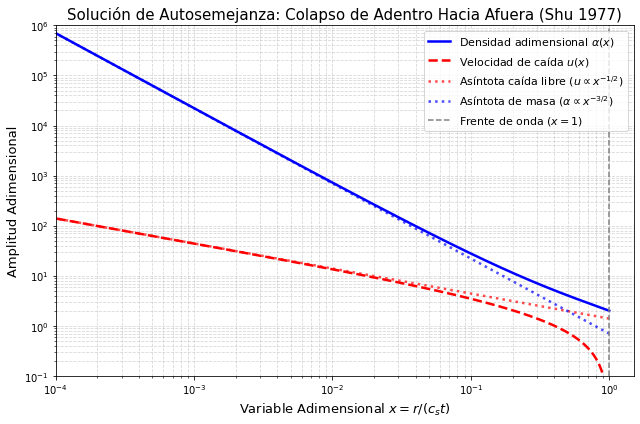

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Ecuaciones de Shu corregidas en el dominio s = -ln(x)
def shu_odes_s(s, y):
    u = y[0]       # u es la velocidad de caída HACIA ADENTRO (positiva)
    alpha = y[1]   # Densidad adimensional
    x = np.exp(-s) # Recuperamos el radio adimensional x

    xpu = x + u
    D = xpu**2 - 1.0  # El denominador correcto de Shu. Siempre es > 0 para x < 1.

    # Salvaguarda numérica por si evaluamos exactamente en la frontera
    if D < 1e-15:
        D = 1e-15

    # Ecuaciones exactas despejadas
    du_dx = (xpu / D) * (2.0 / x - alpha * xpu)
    dalpha_dx = alpha * (-2.0 / x - du_dx / xpu)

    # Regla de la cadena para integrar respecto a s = -ln(x)
    du_ds = -x * du_dx
    dalpha_ds = -x * dalpha_dx

    return [du_ds, dalpha_ds]

# 1. Configuración inicial exacta (Expansión de Taylor, Shu 1977)
w = 1e-4  # Paso microscópico hacia adentro del frente de onda
x_start = 1.0 - w
s_start = -np.log(x_start)

# Coeficientes correctos de 2do orden
u_start = w + 0.5 * (w**2)
alpha_start = 2.0 + 2.0 * w + 2.0 * (w**2)

# 2. Integración Numérica
s_end = -np.log(1e-4) # Integraremos hasta x = 0.0001 (muy cerca del centro)
s_eval = np.linspace(s_start, s_end, 1000)

# RK45 es más que suficiente ahora que la física de los signos está correcta
sol = solve_ivp(shu_odes_s, [s_start, s_end], [u_start, alpha_start],
                t_eval=s_eval, method='RK45', rtol=1e-8, atol=1e-8)

# 3. Recuperación de las variables originales
x_sol = np.exp(-sol.t)
u_sol = sol.y[0]
alpha_sol = sol.y[1]

# 4. Visualización
plt.figure(figsize=(9, 6))

plt.plot(x_sol, alpha_sol, 'b-', linewidth=2.5, label='Densidad adimensional $\\alpha(x)$')
plt.plot(x_sol, u_sol, 'r--', linewidth=2.5, label='Velocidad de caída $u(x)$')

# Asíntotas teóricas cerca del centro (m0 = 0.975)
m0 = 0.975
plt.plot(x_sol, np.sqrt(2 * m0 / x_sol), 'r:', alpha=0.7, linewidth=2.5,
         label='Asíntota caída libre ($u \\propto x^{-1/2}$)')
plt.plot(x_sol, np.sqrt(m0 / (2 * x_sol**3)), 'b:', alpha=0.7, linewidth=2.5,
         label='Asíntota de masa ($\\alpha \\propto x^{-3/2}$)')

plt.axvline(1.0, color='gray', linestyle='--', label='Frente de onda ($x=1$)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-4, 1.5)
plt.ylim(0.1, 1e6)
plt.xlabel('Variable Adimensional $x = r/(c_s t)$', fontsize=13)
plt.ylabel('Amplitud Adimensional', fontsize=13)
plt.title('Solución de Autosemejanza: Colapso de Adentro Hacia Afuera (Shu 1977)', fontsize=15)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Clasificación Observacional de Objetos Estelares Jóvenes (YSOs)

Una vez que el núcleo colapsa, pasamos a la fase protoestelar. La clasificación estándar de las YSOs se basa en la pendiente del Espectro de Energía Distribuida (SED) en el infrarrojo, parametrizada por el índice espectral infrarrojo $\alpha_{IR}$:

$$
\alpha_{IR} = \frac{dlog_{10}(\lambda F_λ)}{d log_{10}(\lambda)}
$$

Este valor se mide típicamente entre 2.2 y 20 $μ$m.

* Clase 0 ($\alpha_{IR}$ muy pronunciado)
  - Características: Objeto extremadamente joven ($t<10^4$yrs). La masa de la envoltura circundante es mayor que la masa de la protoestrella central ($M_{env} > M_\star$).
  - Observación: No emiten en longitudes de onda ópticas ni cercanas al infrarrojo debido a la enorme extinción del polvo; se detectan en submilimétrico y milimétrico (ej. ALMA).
* Clase I ($\alpha_{IR}>0$):
  - Características: La estrella central ya se ha condensado parcialmente, pero sigue rodeada por una densa envoltura de polvo y gas con flujos de acreción activos ($M_{env} \sim M_\star$). El espectro muestra un exceso térmico infrarrojo notable.
* Clase II (Espectros T Tauri clásicos, $-1.5<\alpha_{IR}<0$):
   - Características: La envoltura principal se ha disipado o dispersado. Queda la estrella pre-secuencia principal flanqueada por un disco circumestelar protoplanetario masivo y líneas de emisión prominentes por acreción magnética.
* Clase III (Estrellas T Tauri de líneas débiles / Post-T Tauri, $\alpha_{IR}<−1.5$):
  - Características: El gas y el polvo del disco primordial se han consumido, acumulado en planetesimales, o disipado por fotoevaporación. El espectro se aproxima al de una estrella normal con un débil exceso en infrarrojo lejano.


/var/folders/q2/bqj89jbx5rgb58jm21hskzzm0000gn/T/ipykernel_27377/1262835751.py:11: RuntimeWarning: overflow encountered in exp
  B_lam = (2 * h * c**2 / lam_m**5) / (np.exp(h * c / (lam_m * kB * T)) - 1)


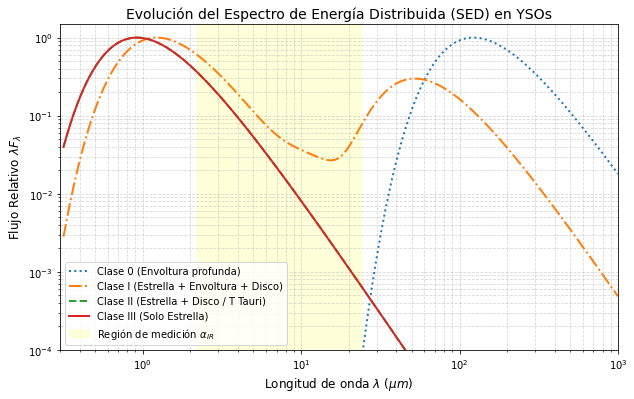

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Definir la función de cuerpo negro (Planck) en términos de lambda * F_lambda
def planck_lambda_flambda(lam_um, T):
    h = 6.626e-34    # J*s
    c = 3.0e8        # m/s
    kB = 1.38e-23    # J/K
    lam_m = lam_um * 1e-6
    # F_lambda proporcional a B_lambda
    B_lam = (2 * h * c**2 / lam_m**5) / (np.exp(h * c / (lam_m * kB * T)) - 1)
    return lam_um * B_lam

# Crear un array de longitudes de onda desde 0.3 hasta 1000 micrómetros
lam = np.logspace(-0.5, 3, 500)

# Modelos simplificados de YSOs (Superposición de Cuerpos Negros)
# Clase 0: Solo vemos la envoltura muy fría
flux_class0 = planck_lambda_flambda(lam, 30)

# Clase I: Protoestrella oculta (T_eff disipada) + Envoltura caliente + Disco
flux_class1 = (1e-6 * planck_lambda_flambda(lam, 3000)) + (2e-4 * planck_lambda_flambda(lam, 300)) + planck_lambda_flambda(lam, 70)

# Clase II (T Tauri Clásica): Estrella visible + Exceso infrarrojo del disco
flux_class2 = planck_lambda_flambda(lam, 4000) + (1.5e-3 * planck_lambda_flambda(lam, 300))

# Clase III (T Tauri de Líneas Débiles): Solo la estrella (cuerpo negro casi puro)
flux_class3 = planck_lambda_flambda(lam, 4000)

# Normalización visual para la gráfica
def normalize(flux): return flux / np.max(flux)

plt.figure(figsize=(10, 6))
plt.plot(lam, normalize(flux_class0), label='Clase 0 (Envoltura profunda)', linewidth=2, linestyle=':')
plt.plot(lam, normalize(flux_class1), label='Clase I (Estrella + Envoltura + Disco)', linewidth=2, linestyle='-.')
plt.plot(lam, normalize(flux_class2), label='Clase II (Estrella + Disco / T Tauri)', linewidth=2, linestyle='--')
plt.plot(lam, normalize(flux_class3), label='Clase III (Solo Estrella)', linewidth=2, linestyle='-')

# Resaltar la zona de medición del índice espectral (2.2 a ~20 um)
plt.axvspan(2.2, 24, color='yellow', alpha=0.15, label='Región de medición $\\alpha_{IR}$')

plt.xscale('log')
plt.yscale('log')
plt.xlim(0.3, 1000)
plt.ylim(1e-4, 1.5)
plt.xlabel('Longitud de onda $\\lambda$ ($\\mu m$)', fontsize=12)
plt.ylabel('Flujo Relativo $\\lambda F_\\lambda$', fontsize=12)
plt.title('Evolución del Espectro de Energía Distribuida (SED) en YSOs', fontsize=14)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

## 4. Evolución en la Pre-Secuencia Principal (PMS).

Una vez que la acreción de masa cesa (gracias a vientos estelares y eyecciones bipolares que limpian la envoltura), la estrella entra oficialmente en la fase de Pre-Secuencia Principal, gobernada enteramente por la contracción gravitacional sin fuentes de energía nuclear estables en el núcleo (aún no quema hidrógeno de manera sostenida).

### 4.1 La Escala de Tiempo de Kelvin-Helmholtz ($t_{KH}$)

La energía que radia la estrella PMS proviene exclusivamente de la conversión de energía potencial gravitacional en calor radiado:

$$
t_{KH}\approx \frac{GM^2}{RL}
$$

Para una estrella tipo solar, esta escala de tiempo es de unos $3\times10^7$ años, lo cual marca la duración de la fase PMS antes de encender el hidrógeno.

### 4.2 Trazas de Hayashi y Henyey en el Diagrama HR

En el diagrama Hertzsprung-Russell (HR), las estrellas PMS descienden desde las regiones frías y luminosas hacia la Secuencia Principal a través de dos regímenes evolutivos distintos:
1. La Fase Convectiva (La Traza de Hayashi):
  - Física: Estrellas totalmente convectivas y de baja masa (o fases tempranas muy expandidas de estrellas solares). Debido a la opacidad masiva del gas molecular frío y polvoriento, la energía se transporta por convección.
  - Trayectoria en el HR: Descenso casi vertical (temperatura efectiva $T_{eff}$ casi constante, mientras la luminosidad $L$ cae drásticamente porque el radio estelar disminuye según la ley de Stefan-Boltzmann: $L=4\pi R^2 \sigma_{SB}T^4$).

2. La Fase Radiativa (La Traza de Henyey):
  - Física: A medida que la estrella se contrae, su temperatura interna sube, el hidrógeno ionizado se recombina parcialmente y la opacidad central disminuye. Se desarrolla un núcleo radiativo interno.
  -Trayectoria en el HR: La traza se curva hacia la derecha, volviéndose horizontal (la luminosidad se estabiliza aproximadamente mientras la temperatura efectiva aumenta de manera constante).
3. Llegada a la ZAMS (Zero-Age Main Sequence):
  - Cuando la temperatura del núcleo alcanza $\approx10^7$K, se enciende la cadena protón-protón (reacciones nucleares estables de hidrógeno). La presión termonuclear contrarresta por completo la gravedad y la contracción se detiene. La estrella entra formalmente en la Secuencia Principal.

## Lecturas recomendadas de la semana
1. André, P., Di Francesco, J., Ward-Thompson, D., et al. (2014). "From Filamentary Networks to Dense Cores in Molecular Clouds". Protostars and Planets VI, University of Arizona Press, pp. 27-51.
  
    *Relevancia*: El capítulo canónico que revolucionó la visión tradicional de las esferas de Bonnor-Ebert aisladas, demostrando que los núcleos pre-estelares se forman primariamente dentro de redes universales de filamentos interestelares mapeados por Herschel.
    
2. Dunham, M. M., Stutz, A. M., Allen, L. E., et al. (2014). "The Evolution of Protostars: Insights from Herschel". Protostars and Planets VI, University of Arizona Press, pp. 195-218.
  
    *Relevancia*: Referencia fundamental para la clasificación observacional de YSOs (Clases 0 a III), detallando cómo los datos infrarrojos y submilimétricos revelan la física de la envoltura y la acreción temprana.

3. Hartmann, L., Herczeg, G., & Calvet, N. (2016). "Accretion onto Pre-Main-Sequence Stars". Annual Review of Astronomy and Astrophysics, 54, 135-180.
  
    *Relevancia*: Análisis exhaustivo sobre las tasas de acreción de gas, magnetosferas estelares y la transición dinámica durante la evolución Pre-Secuencia Principal (fases T Tauri).

4. Krumholz, M. R. (2014). "The Star Formation Rate and Efficiency Across Cosmic Time". Physics Reports, 539, 49-134.
  
    *Relevancia*: Un marco teórico monumental que conecta la física de núcleos individuales (como el colapso de Shu y la estabilidad de Bonnor-Ebert) con las leyes globales de formación estelar en galaxias.

5. Offner, S. S. R., Clarke, S. D., Whelan, E. T., et al. (2022). "The Origin of Star Clusters and the Initial Mass Function". Protostars and Planets VII, Astronomical Society of the Pacific / arXiv:2203.09543.
  
    *Relevancia*: Estado del arte reciente sobre cómo los núcleos colapsan jerárquicamente para dar origen no solo a estrellas aisladas, sino a cúmulos completos, discutiendo la interacción entre turbulencia y gravedad.

## Ejercicios para los estudiantes

### Ejercicio 1: Límite de Estabilidad de Bonnor-Ebert (Analítico)
Considere un núcleo pre-estelar isotérmico con una temperatura cinéntica $T=12$K y un peso molecular medio $\mu=2.33$. Suponga que está confinado por el medio interestelar con una presión externa correspondiente a una densidad numérica ambiental de $n_{H_2}=5\times10^3$cm$^{-3}$ y la misma temperatura.

1. Calcule la velocidad isotérmica del sonido $c_s$ en km/s.
2. Determine la presión externa $P_{ext}$ en unidades cgs (dyn cm$^{-2}$), asumiendo $ \rho_{ext} = \mu m_H n_{H_2} $.
3. Calcule la Masa Crítica de Bonnor-Ebert ($M_{BE}$) en masas solares ($M_\odot$). Si el núcleo real tiene una masa de $3.5M_\odot$, ¿es estable o colapsará?

### Ejercicio 2: Tasa de Acreción de Shu y Masa Acumulada (Analítico)
En el modelo de colapso de "adentro hacia afuera" de Frank Shu (Esfera Isoterma Singular), la tasa de acreción de masa sobre la protoestrella central es constante e independiente del tiempo.
1. Utilizando la velocidad del sonido isotérmica para $T=10$K ($c_s\approx0.2$km/s) y la constante adimensional de Shu $m_0=0.975$, calcule la tasa de acreción $\dot{M}$ en $M_\odot$.
2. Si la fase de envoltura densa (Clase 0 + Clase I) dura aproximadamente $t_{env}=5\times10^5$ años, ¿cuál es la masa total acumulada por la protoestrella al final de esta fase?

### Ejercicio 3: Cálculo Numérico de la Masa de Bonnor-Ebert (Computacional - Python)
Escriba un script en Python que calcule y grafique cómo cambia la Masa Crítica de Bonnor-Ebert ($M_{BE}$) en función de la temperatura del núcleo ($T$ de 5K a 30K) para tres presiones externas diferentes ($P_{ext}/k_B=[10^4,10^5,10^6]$ K cm$^{-3}$).

### Ejercicio 4: Simulación de Crecimiento de Masa Protoestelar por Acreción (Computacional - Python)
Simule la evolución temporal de la masa de una protoestrella durante su fase de acreción envolvente según el modelo de Shu, y grafique cómo crece la masa central ($M_\star$) y cómo disminuye la masa de la envoltura restante ($M_{env}$) partiendo de una masa inicial de núcleo $M_{core}=5.0M_\odot$.

In [4]:
## Escriba aquí su solución